# 07b Visualize $\phi_{\rm amp,max}(m_a)$

`07a` の出力と `04b` の `phi_needed(m_a)` を重ねて、どの質量帯で

```math
\phi_{\rm needed}(m_a) < \phi_{\rm amp,max}(m_a)
```

になりうるかを 2 次元グラフで見る notebook です。

注意:

- `\phi_{\rm amp,max}` は現段階では phenomenological な bound です。
- 既定では split 実行で得た `results/07a-phi-amp-max-split/phi_amp_max_scan.csv` を読みます。
- `\rho_\phi(z_{\rm eval}) \le f_{\rm DM}\rho_{\rm DM}(z_{\rm eval})` を使っています。
- 単位系や canonical normalization の厳密な扱いは、今後さらに確認すべき点です。
        


In [1]:
from pathlib import Path
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
PHI_MAX_CSV = ROOT / "results/07a-phi-amp-max-split/phi_amp_max_scan.csv"
PHI_NEEDED_CSV = ROOT / "results/04b-rtau-needed/Rtau_phi_needed_scan.csv"


def read_csv(path):
    with path.open() as f:
        return list(csv.DictReader(f))


phi_max_rows = read_csv(PHI_MAX_CSV)
phi_needed_rows = read_csv(PHI_NEEDED_CSV)

phi_max_by_mass = {float(row["mass_eV"]): float(row["phi_amp_max"]) for row in phi_max_rows}
case_rows = defaultdict(list)
for row in phi_needed_rows:
    case_rows[row["case_name"]].append(row)

case_names = sorted(case_rows)
case_names
        


['nphi_1_Lcut_800',
 'nphi_1_no_cut',
 'nphi_2_Lcut_800',
 'nphi_2_no_cut',
 'nphi_3_Lcut_800',
 'nphi_3_no_cut']

## $\phi_{\rm amp,max}(m_a)$ 単体
        


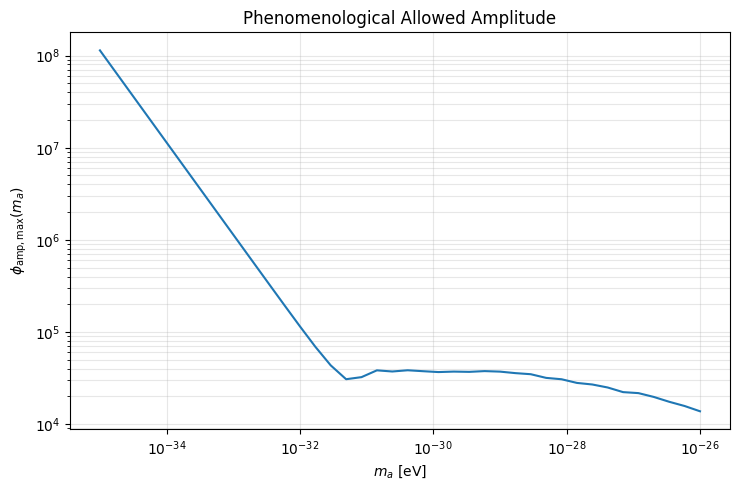

In [2]:
masses = np.array(sorted(phi_max_by_mass))
phi_max = np.array([phi_max_by_mass[m] for m in masses])

plt.figure(figsize=(7.5, 5))
plt.loglog(masses, phi_max)
plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$\phi_{\rm amp,max}(m_a)$")
plt.title(r"Phenomenological Allowed Amplitude")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
        


## $\phi_{\rm needed}(m_a)$ と $\phi_{\rm amp,max}(m_a)$ の重ね合わせ

下側にあるほど必要振幅が小さく、上側にあるほど許容振幅が大きいです。  
したがって、

```math
\phi_{\rm needed}(m_a) < \phi_{\rm amp,max}(m_a)
```

なら、その質量帯は有望候補になります。
        


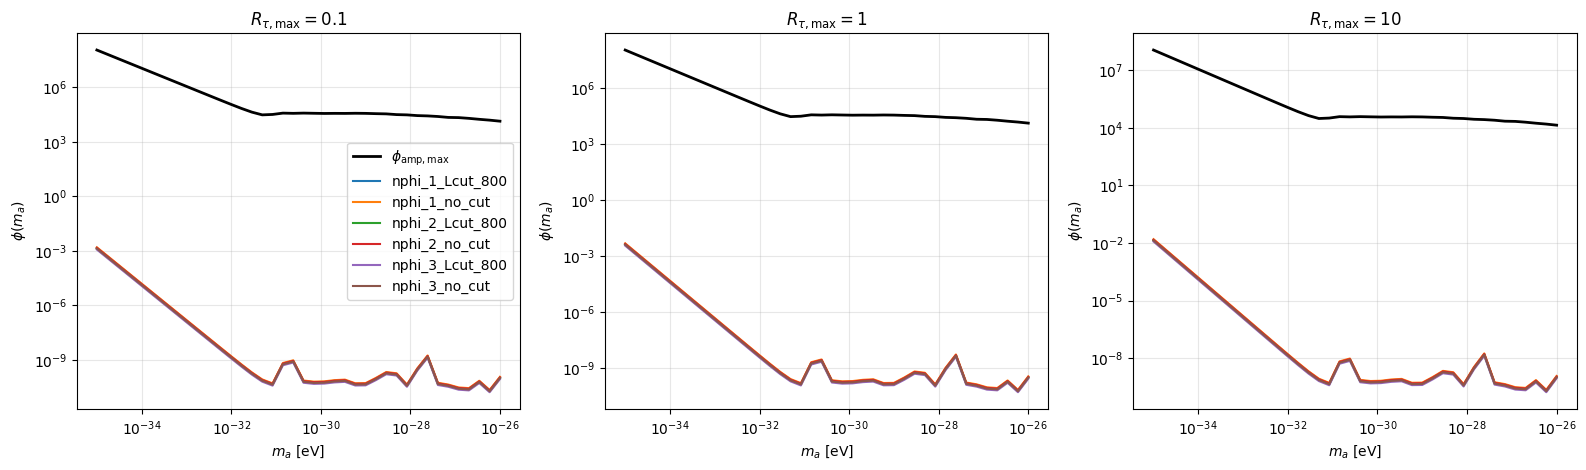

In [3]:
targets = ["0.1", "1", "10"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)

for ax, target in zip(axes, targets):
    ax.loglog(masses, phi_max, color="black", lw=2, label=r"$\phi_{\rm amp,max}$")
    for case_name in case_names:
        rows = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
        case_m = np.array([float(row["mass_eV"]) for row in rows])
        case_phi = np.array([float(row[f"phi_needed_target_{target}"]) for row in rows])
        ax.loglog(case_m, case_phi, label=case_name)
    ax.set_xlabel(r"$m_a\ [{\rm eV}]$")
    ax.set_ylabel(r"$\phi(m_a)$")
    ax.set_title(rf"$R_{{\tau,\max}} = {target}$")
    ax.grid(True, which="both", alpha=0.3)

axes[0].legend()
plt.tight_layout()
plt.show()
        


## 比 $\phi_{\rm needed}/\phi_{\rm amp,max}$

これが 1 未満なら viability がある、と見ることができます。
        


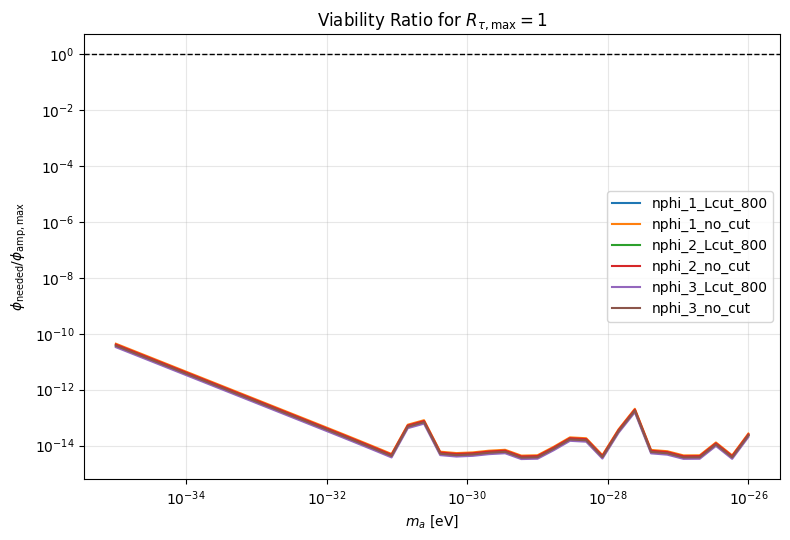

In [4]:
target = "1"

plt.figure(figsize=(8, 5.5))
plt.axhline(1.0, color="black", ls="--", lw=1.0)
for case_name in case_names:
    rows = sorted(case_rows[case_name], key=lambda r: float(r["mass_eV"]))
    case_m = np.array([float(row["mass_eV"]) for row in rows])
    case_phi = np.array([float(row[f"phi_needed_target_{target}"]) for row in rows])
    case_phi_max = np.array([phi_max_by_mass[m] for m in case_m])
    plt.loglog(case_m, case_phi / case_phi_max, label=case_name)

plt.xlabel(r"$m_a\ [{\rm eV}]$")
plt.ylabel(r"$\phi_{\rm needed}/\phi_{\rm amp,max}$")
plt.title(rf"Viability Ratio for $R_{{\tau,\max}}={target}$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
        


## best mass での一覧
        


In [5]:
summary = []
for case_name in case_names:
    rows = case_rows[case_name]
    best = max(rows, key=lambda r: float(r["Rtau_max_unit"]))
    mass = float(best["mass_eV"])
    summary.append(
        {
            "case": case_name,
            "m_best_eV": mass,
            "phi_needed_R1": float(best["phi_needed_target_1"]),
            "phi_amp_max": phi_max_by_mass[mass],
            "ratio_R1": float(best["phi_needed_target_1"]) / phi_max_by_mass[mass],
        }
    )

summary
        


[{'case': 'nphi_1_Lcut_800',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 6.4098990004064e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio_R1': 4.07011254109695e-15},
 {'case': 'nphi_1_no_cut',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 6.997706803034962e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio_R1': 4.443354601397973e-15},
 {'case': 'nphi_2_Lcut_800',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 5.90697349918006e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio_R1': 3.750768446962391e-15},
 {'case': 'nphi_2_no_cut',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 6.540341161808949e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio_R1': 4.1529397864215084e-15},
 {'case': 'nphi_3_Lcut_800',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 5.263771321026853e-11,
  'phi_amp_max': 15748.702119865331,
  'ratio_R1': 3.3423524560713862e-15},
 {'case': 'nphi_3_no_cut',
  'm_best_eV': 5.878016072274924e-27,
  'phi_needed_R1': 5.